# Multifactor Dispersion Bias — Part (ii): Verification Walkthrough

A short, results-first tour of the numerical verification of **Equation (6), Part (ii)**
(diagonal-Gram case, $G_\infty = I_k$): configure a model, run the sweep, and watch the
predicted and observed loading-direction alignment converge as the ambient dimension
$p$ grows.

For each factor $j$, as $p \to \infty$ (conditional on $F$, almost surely):

$$\sin^2\angle(h_j, \bar b_j) \;\longrightarrow\;
\underbrace{\frac{\delta^2}{n\rho_j + \delta^2}}_{\text{floor}}
\;+\;
\underbrace{\frac{n\rho_j}{n\rho_j + \delta^2}}_{\text{weight}}\cdot
\underbrace{\sin^2\angle(\hat w_j, e_j)}_{\text{rotation}}.$$

We compute the **LHS** (observed $\sin^2$ from simulated returns) and the **RHS**
(predicted from the realized factor returns) over a grid of $p$, and confirm the gap
between them shrinks to zero.

> For the engine internals and design rationale, see
> [theorem_partii_walkthrough.ipynb](theorem_partii_walkthrough.ipynb).

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the notebook quiet

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_theorem_partii import DispersionBiasExperiment, print_summary
from fl_graphics import plot_all

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)
print("ready")

ready


## 1 — Configure

A run is a **model** (what factor model) and a **design** (the sweep + return
process). The built-in defaults are the canonical diagonal-Gram model — a market-like
factor 1 plus two zero-mean style factors, factor vols $\sigma=[.16,.08,.06]$, idio vol
$0.4$. Here we pair it with a small, fast design so the convergence trend shows up in
seconds.

In [2]:
model = ModelSpec( # canonical diagonal-Gram model but written out in full for clarity
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],                 # volatilities; squared into F
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 1.0},   # market-like factor
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},  # delta = 0.4 -> delta^2 = 0.16
)                       
design = DesignSpec(                      # heavy-tailed returns sweep
    n_values=[63],
    p_values=[200, 500, 1000, 2000, 5000, 10000, 15000, 20000],
    n_reps=1000,
    random_seed=20260511,
    factor_return_sampler = {"distribution": "normal", "loc": 0.0, "scale": 1.0},  # Gaussian factor returns
    idio_return_sampler = {"distribution": "normal", "loc": 0.0, "scale": 1.0},    # Gaussian idiosyncratic returns
    # factor_return_sampler = {"distribution": "student_t", "df": 3, "loc": 0.0, "scale": 1.0},  # heavy-tailed factor returns
    # idio_return_sampler = {"distribution": "student_t", "df": 4, "loc": 0.0, "scale": 1.0},    # heavy-tailed idiosyncratic returns
    sampling="nested", # nested p sampler
)
# For the full canonical run, use: design = DesignSpec()   # 16,200 rows

print(f"k={model.k_factors}, factor_vols={model.factor_vols}")
print(f"n={design.n_values}, p={design.p_values}, reps={design.n_reps}")

k=3, factor_vols=[0.16, 0.08, 0.06]
n=[63], p=[200, 500, 1000, 2000, 5000, 10000, 15000, 20000], reps=1000


## 2 — Run the sweep

`run_experiment(model, design, probe)` builds a fresh model per $(n, p)$ cell,
simulates `n_reps` replications of returns, runs the LHS/RHS analyses, and returns a
tidy per-replication DataFrame. One line.

In [3]:
df = run_experiment(model, design, DispersionBiasExperiment())
print("rows:", len(df), " columns:", list(df.columns))
df.head()

replicate:   0%|          | 0/1000 [00:00<?, ?rep/s]

replicate:   0%|          | 3/1000 [00:00<01:15, 13.15rep/s]

replicate:   0%|          | 5/1000 [00:00<01:24, 11.84rep/s]

replicate:   1%|          | 8/1000 [00:00<00:59, 16.54rep/s]

replicate:   1%|          | 11/1000 [00:00<00:50, 19.56rep/s]

...

replicate: 100%|█████████▉| 995/1000 [00:38<00:00, 25.50rep/s]

replicate: 100%|█████████▉| 998/1000 [00:39<00:00, 25.07rep/s]

replicate: 100%|██████████| 1000/1000 [00:39<00:00, 25.55rep/s]

rows: 24000  columns: ['n', 'p', 'j', 'sin2_j', 'rhs', 'gap', 'floor', 'rotation', 'rho', 'rep']


,n,p,j,sin2_j,rhs,gap,floor,rotation,rho,rep
0,63,200,1,0.077935,0.067114,0.010821,0.055294,0.012512,0.043391,0
1,63,200,2,0.459102,0.480341,-0.021239,0.297113,0.260679,0.006008,0
2,63,200,3,0.903252,0.657755,0.245497,0.531283,0.269827,0.002241,0
3,63,500,1,0.072385,0.067977,0.004408,0.055746,0.012953,0.043018,0
4,63,500,2,0.448417,0.490242,-0.041825,0.295931,0.275983,0.006042,0


## 3 — The confirmation

The RMSE of the gap $(\sin^2\angle - \text{RHS})$ per $(n, p, j)$ should **fall as $p$
grows** — that decline is the numerical confirmation of the theorem. The weakest factor
($j=3$) converges slowest, as the theory predicts.

In [4]:
print_summary(df)


RMSE of (sin²∠ − RHS)  [smaller is better; should → 0 as p grows]

             j=1     j=2     j=3
n  p                            
63 200   0.00575 0.11084 0.16305
   500   0.00357 0.05938 0.07372
   1000  0.00255 0.03387 0.04064
   2000  0.00177 0.02694 0.02930
   5000  0.00115 0.01446 0.01559
   10000 0.00079 0.01188 0.01245
   15000 0.00063 0.00909 0.00942
   20000 0.00056 0.00777 0.00806



## 4 — Figures

The gap-vs-$p$ convergence (should trend to zero) and the observed-vs-predicted
scatter at the second-largest $p$ (should hug the 45° line).

In [5]:
from IPython.display import Image, display

plot_all(df, OUT_DIR, n_show=design.n_values[0])
for fname in ["fig_theorem1_convergence_v2.png", "fig_theorem1_scatter_v2.png"]:
    display(Image(filename=str(OUT_DIR / fname)))

## 5 — Cleaner convergence: nested sampling

Set `sampling="nested"` to draw one superset at $p_{\max}$ per replicate and take each
smaller $p$ as its first-$p$ asset subset — so every $p$ sees the *same* assets. That
removes the cross-$p$ sampling noise and gives a clean monotone-in-$p$ curve. Only the
one field changes; the model and the probe are identical.

In [6]:
nested = DesignSpec(
    n_values=[60], p_values=[200, 500, 1000, 2000, 5000],
    n_reps=40, random_seed=20260511,
    sampling="nested",
)
df_nested = run_experiment(model, nested, DispersionBiasExperiment())

rmse = (df_nested[df_nested.j == 1].groupby("p")["gap"]
        .apply(lambda g: float((g ** 2).mean() ** 0.5)))
print("nested RMSE(j=1) by p (falls monotonically):")
print(rmse.round(4).to_string())

replicate:   0%|          | 0/40 [00:00<?, ?rep/s]

replicate:  18%|█▊        | 7/40 [00:00<00:00, 66.65rep/s]

replicate:  55%|█████▌    | 22/40 [00:00<00:00, 113.32rep/s]

replicate:  92%|█████████▎| 37/40 [00:00<00:00, 129.18rep/s]

replicate: 100%|██████████| 40/40 [00:00<00:00, 121.94rep/s]

nested RMSE(j=1) by p (falls monotonically):
p
200     0.0059
500     0.0039
1000    0.0024
2000    0.0018
5000    0.0012


## Running the full experiment

Swap in `design = DesignSpec()` above for the canonical run ($3$ factors $\times\,300$
reps $\times\,6$ $p$-values $\times\,3$ $n$-values $= 16{,}200$ rows), or run it from the
command line:

```bash
python sim_theorem_partii.py --plot-save                      # built-in defaults
python sim_theorem_partii.py sim_thmptii_spec.json --plot-save # single-file spec
python sim_theorem_partii.py experiment_spec.nested.example.json --plot-save
```

Outputs (parquet + the three figures) land in `results/MM-DD_run_NN/`.

## 6 — Decomposition figures: out-of-subspace + in-subspace, with uncertainty

Ethan's 9-panel decomposition (from `ex-1.ipynb`), run on **this** notebook's experiment. Each
figure has three rows per factor:

- **sin² (additive):** stacked bars *out-of-subspace* $\delta^2/(n\lambda_{n,j}+\delta^2)$ +
  *in-subspace*, with the **measured** $\sin^2\angle(h_j,\bar b_j)$ drawn as the black line; caps are 95% CIs.
- **gap:** paired $\text{mean}(\text{measured}-\text{theory})$ in sin², with a zero reference (0 ⇒ theory matches).
- **in-subspace share:** in-sub / (oos + in-sub) of the predicted total.

Three sweeps: growing $p$ (fixed $n$), fixed $p=3000$ growing $n$, and the same with `nest_time=True`.
CI width follows `n_reps` ($\mathrm{SE}=\mathrm{sd}/\sqrt{R}$).

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Styling + Eq.(17) decomposition / gap / in-subspace-share helpers (Ethan's ex-1 panels).
NAVY, GRAY = "#1f3864", "#555555"
FACTOR_COLORS = ["tab:blue", "tab:orange", "tab:green"]
DEG_TICKS  = ([0, 30, 60, 90], ["0°", "30°", "60°", "90°"])
SIN2_TICKS = ([0, 0.25, 0.5, 0.75, 1.0], ["0", "0.25", "0.50", "0.75", "1.0"])
N_FIXED = design.n_values[0]      # n held fixed across the p-sweep above
R_REPS  = design.n_reps           # replicates -> CI width (SE = sd/sqrt(R))

LABEL_MEAS  = r"measured $\angle(h, \bar b)$"
LABEL_OOS   = r"out-of-subspace: $\delta^2/(n\lambda_{n,j}+\delta^2)$"
LABEL_INSUB = "in-subspace"

def to_deg(v):
    """sin^2 of an angle -> the angle in degrees."""
    return np.degrees(np.arcsin(np.sqrt(np.clip(v, 0.0, 1.0))))

def enrich(frame):
    """Add the sin^2 / angle plotting columns to a raw experiment frame."""
    return frame.assign(
        s2_meas=frame["sin2_j"], s2_theory=frame["rhs"], s2_oos=frame["floor"],
        ang_meas=to_deg(frame["sin2_j"]), ang_theory=to_deg(frame["rhs"]), ang_oos=to_deg(frame["floor"]),
    )

def summarize(frame, key):
    """Per (key, factor j): component means + SEMs of measured/theory and the paired
    gap (= measured - theory), over the replicate axis. SE = sd/sqrt(n_reps)."""
    g = frame.assign(gap=frame["s2_meas"] - frame["s2_theory"])
    return g.groupby([key, "j"]).agg(
        s2_meas=("s2_meas", "mean"),       s2_meas_se=("s2_meas", "sem"),
        s2_theory=("s2_theory", "mean"),   s2_theory_se=("s2_theory", "sem"),
        s2_oos=("s2_oos", "mean"),
        ang_meas=("ang_meas", "mean"),     ang_meas_se=("ang_meas", "sem"),
        ang_theory=("ang_theory", "mean"), ang_theory_se=("ang_theory", "sem"),
        ang_oos=("ang_oos", "mean"),
        gap=("gap", "mean"),               gap_se=("gap", "sem"),
    ).reset_index()

def decomp_panel(ax, cats, meas, oos, insub, meas_se=None, total_se=None, width=0.7):
    """Stacked theory bars (out-of-subspace + in-subspace) with the measured value as a
    black line; optional 95% CI caps on the measured line and the stack total."""
    x = np.arange(len(cats))
    ax.bar(x, oos,   width, color="#4878a8", label=LABEL_OOS)
    ax.bar(x, insub, width, bottom=oos, color="#f28e2b", label=LABEL_INSUB)
    ax.plot(x, meas, "o-", color="black", label=LABEL_MEAS, zorder=5)
    cap = dict(fmt="none", ecolor="black", elinewidth=0.8, capsize=2, zorder=5)
    if meas_se is not None:
        ax.errorbar(x, meas, yerr=1.96 * meas_se, **cap)
    if total_se is not None:
        ax.errorbar(x, oos + insub, yerr=1.96 * total_se, **cap)
    ax.set_xticks(x, cats, fontsize=8)
    return x

def gap_panel(ax, cats, gap, gap_se, color):
    """Paired gap = mean(measured - theory) in sin^2, with 95% CI and a zero reference."""
    x = np.arange(len(cats))
    ax.axhline(0, color="0.6", lw=0.8, ls="--")
    ax.errorbar(x, gap, yerr=1.96 * gap_se, fmt="o-", color=color, ms=4, lw=1.2, capsize=2)
    ax.set_xticks(x, cats, fontsize=8)
    return x

def frac_panel(ax, cats, frac, color):
    """In-subspace share = in-sub / (oos + in-sub) of the predicted total."""
    x = np.arange(len(cats))
    ax.bar(x, frac, 0.7, color=color, alpha=0.55, label="in-subspace share")
    ax.set_xticks(x, cats, fontsize=8)
    return x

CAPTION = (
    "Top — sin²∠(h, b̄) = out-of-subspace + in-subspace (additive); black line = measured; "
    f"caps = 95% CI (R = {R_REPS}, SE = sd/√R).   "
    "Middle — gap = mean(measured − theory) sin² (paired): 0 ⇒ theory matches, >0 ⇒ measured exceeds prediction.   "
    "Bottom — in-subspace share = in-sub/(oos+in-sub) of the predicted total."
)

# Growing-p decomposition reuses the heavy-tail df from the sweep above.
avg = summarize(enrich(df), "p")
P_VALUES = sorted(df["p"].unique())
print(f"helpers ready; p-sweep avg rows: {len(avg)}, R = {R_REPS}")

helpers ready; p-sweep avg rows: 24, R = 1000


/private/tmp/ipykernel_55339/761275698.py:25: UserWarning: Glyph 8736 (\N{ANGLE}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / "fig_decomp_growing_p.png", dpi=150, bbox_inches="tight")


/private/tmp/ipykernel_55339/761275698.py:25: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / "fig_decomp_growing_p.png", dpi=150, bbox_inches="tight")


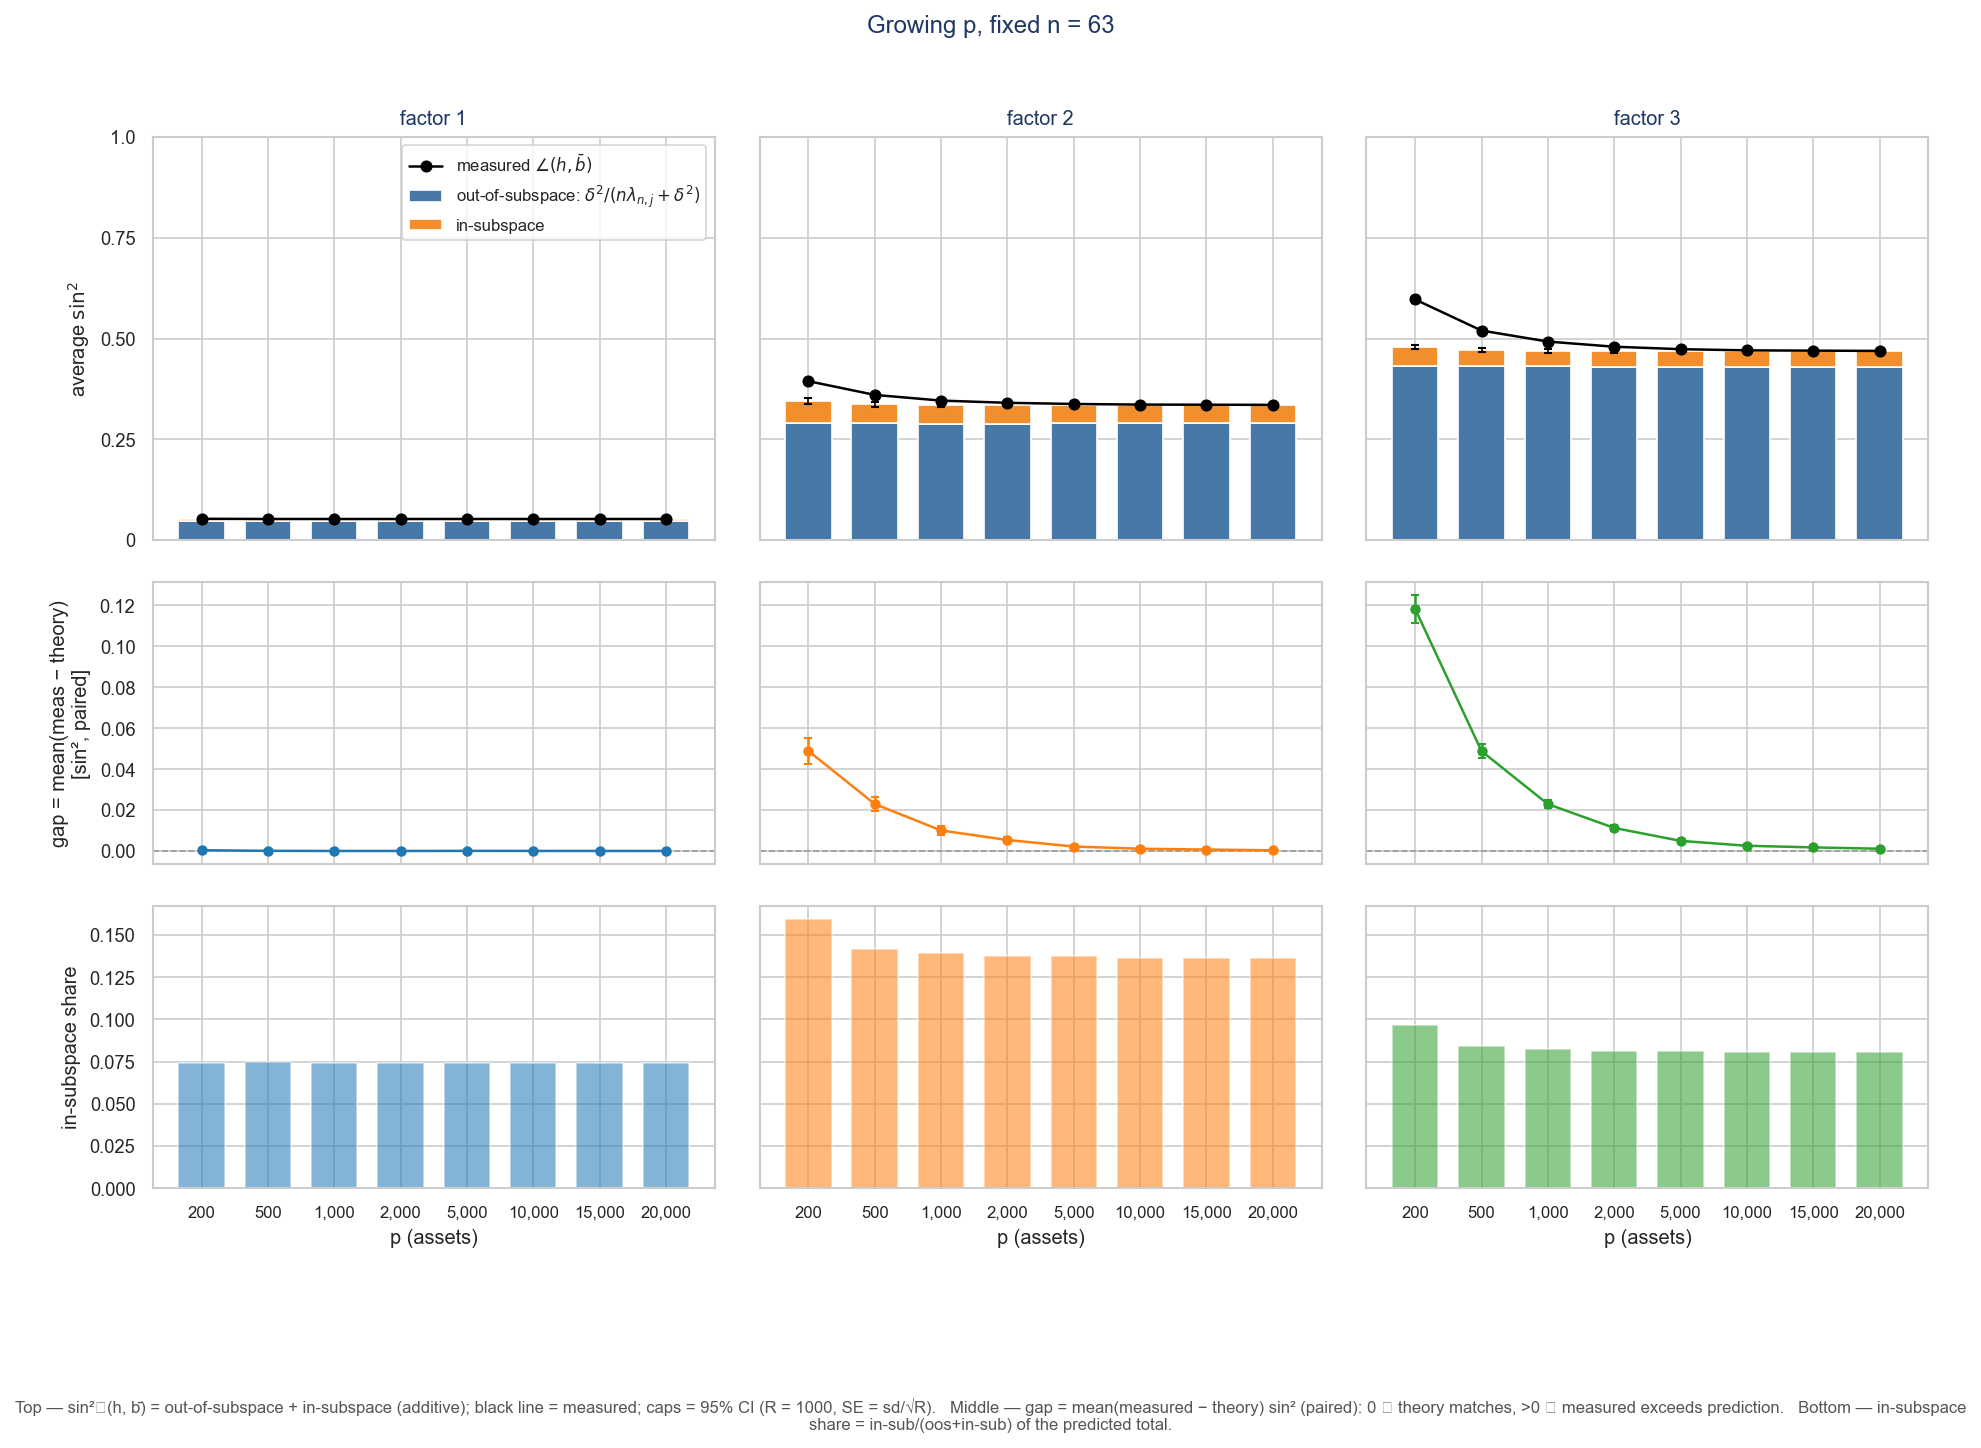

In [8]:
# Growing p, fixed n: Eq.(17) decomposition + diagnostics (9-panel).

fig, axes = plt.subplots(3, 3, figsize=(13.3, 9.6), sharex="col", sharey="row",
                         gridspec_kw={"height_ratios": [1, 0.7, 0.7]})
fig.subplots_adjust(left=0.08, right=0.97, top=0.90, bottom=0.17, hspace=0.13, wspace=0.08)
cats = [f"{p:,}" for p in P_VALUES]
for j in (1, 2, 3):
    a = avg[avg["j"] == j].set_index("p").loc[P_VALUES]
    decomp_panel(axes[0, j-1], cats, a["s2_meas"].to_numpy(), a["s2_oos"].to_numpy(),
                 (a["s2_theory"] - a["s2_oos"]).to_numpy(),
                 meas_se=a["s2_meas_se"].to_numpy(), total_se=a["s2_theory_se"].to_numpy())
    axes[0, j-1].set_title(f"factor {j}", color=NAVY)
    gap_panel(axes[1, j-1], cats, a["gap"].to_numpy(), a["gap_se"].to_numpy(), FACTOR_COLORS[j-1])
    insub = (a["s2_theory"] - a["s2_oos"]).to_numpy()
    frac_panel(axes[2, j-1], cats, insub / a["s2_theory"].to_numpy(), FACTOR_COLORS[j-1])
    axes[2, j-1].set_xlabel("p (assets)")
axes[0, 0].set_ylim(0, 1); axes[0, 0].set_yticks(*SIN2_TICKS); axes[0, 0].set_ylabel(r"average $\sin^2$")
axes[1, 0].set_ylabel("gap = mean(meas − theory)\n[sin², paired]")
axes[2, 0].set_ylabel("in-subspace share")
axes[0, 0].legend(fontsize=8, loc="upper right")
for ax in axes.flat:
    ax.label_outer()
fig.suptitle(f"Growing p, fixed n = {N_FIXED}", color=NAVY, y=0.985)
fig.text(0.5, 0.025, CAPTION, ha="center", va="top", fontsize=8, color=GRAY, wrap=True)
fig.savefig(OUT_DIR / "fig_decomp_growing_p.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(OUT_DIR / "fig_decomp_growing_p.png")))

replicate:   0%|          | 0/1000 [00:00<?, ?rep/s]

replicate:   0%|          | 5/1000 [00:00<00:23, 42.81rep/s]

replicate:   1%|          | 10/1000 [00:00<00:21, 46.48rep/s]

replicate:   2%|▏         | 16/1000 [00:00<00:20, 48.80rep/s]

replicate:   2%|▏         | 22/1000 [00:00<00:19, 49.44rep/s]

...

replicate:  99%|█████████▉| 989/1000 [00:20<00:00, 48.39rep/s]

replicate:  99%|█████████▉| 994/1000 [00:20<00:00, 48.82rep/s]

replicate: 100%|█████████▉| 999/1000 [00:20<00:00, 48.84rep/s]

replicate: 100%|██████████| 1000/1000 [00:20<00:00, 48.46rep/s]

/private/tmp/ipykernel_55339/879108771.py:32: UserWarning: Glyph 8736 (\N{ANGLE}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / "fig_decomp_growing_n.png", dpi=150, bbox_inches="tight")
/private/tmp/ipykernel_55339/879108771.py:32: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / "fig_decomp_growing_n.png", dpi=150, bbox_inches="tight")


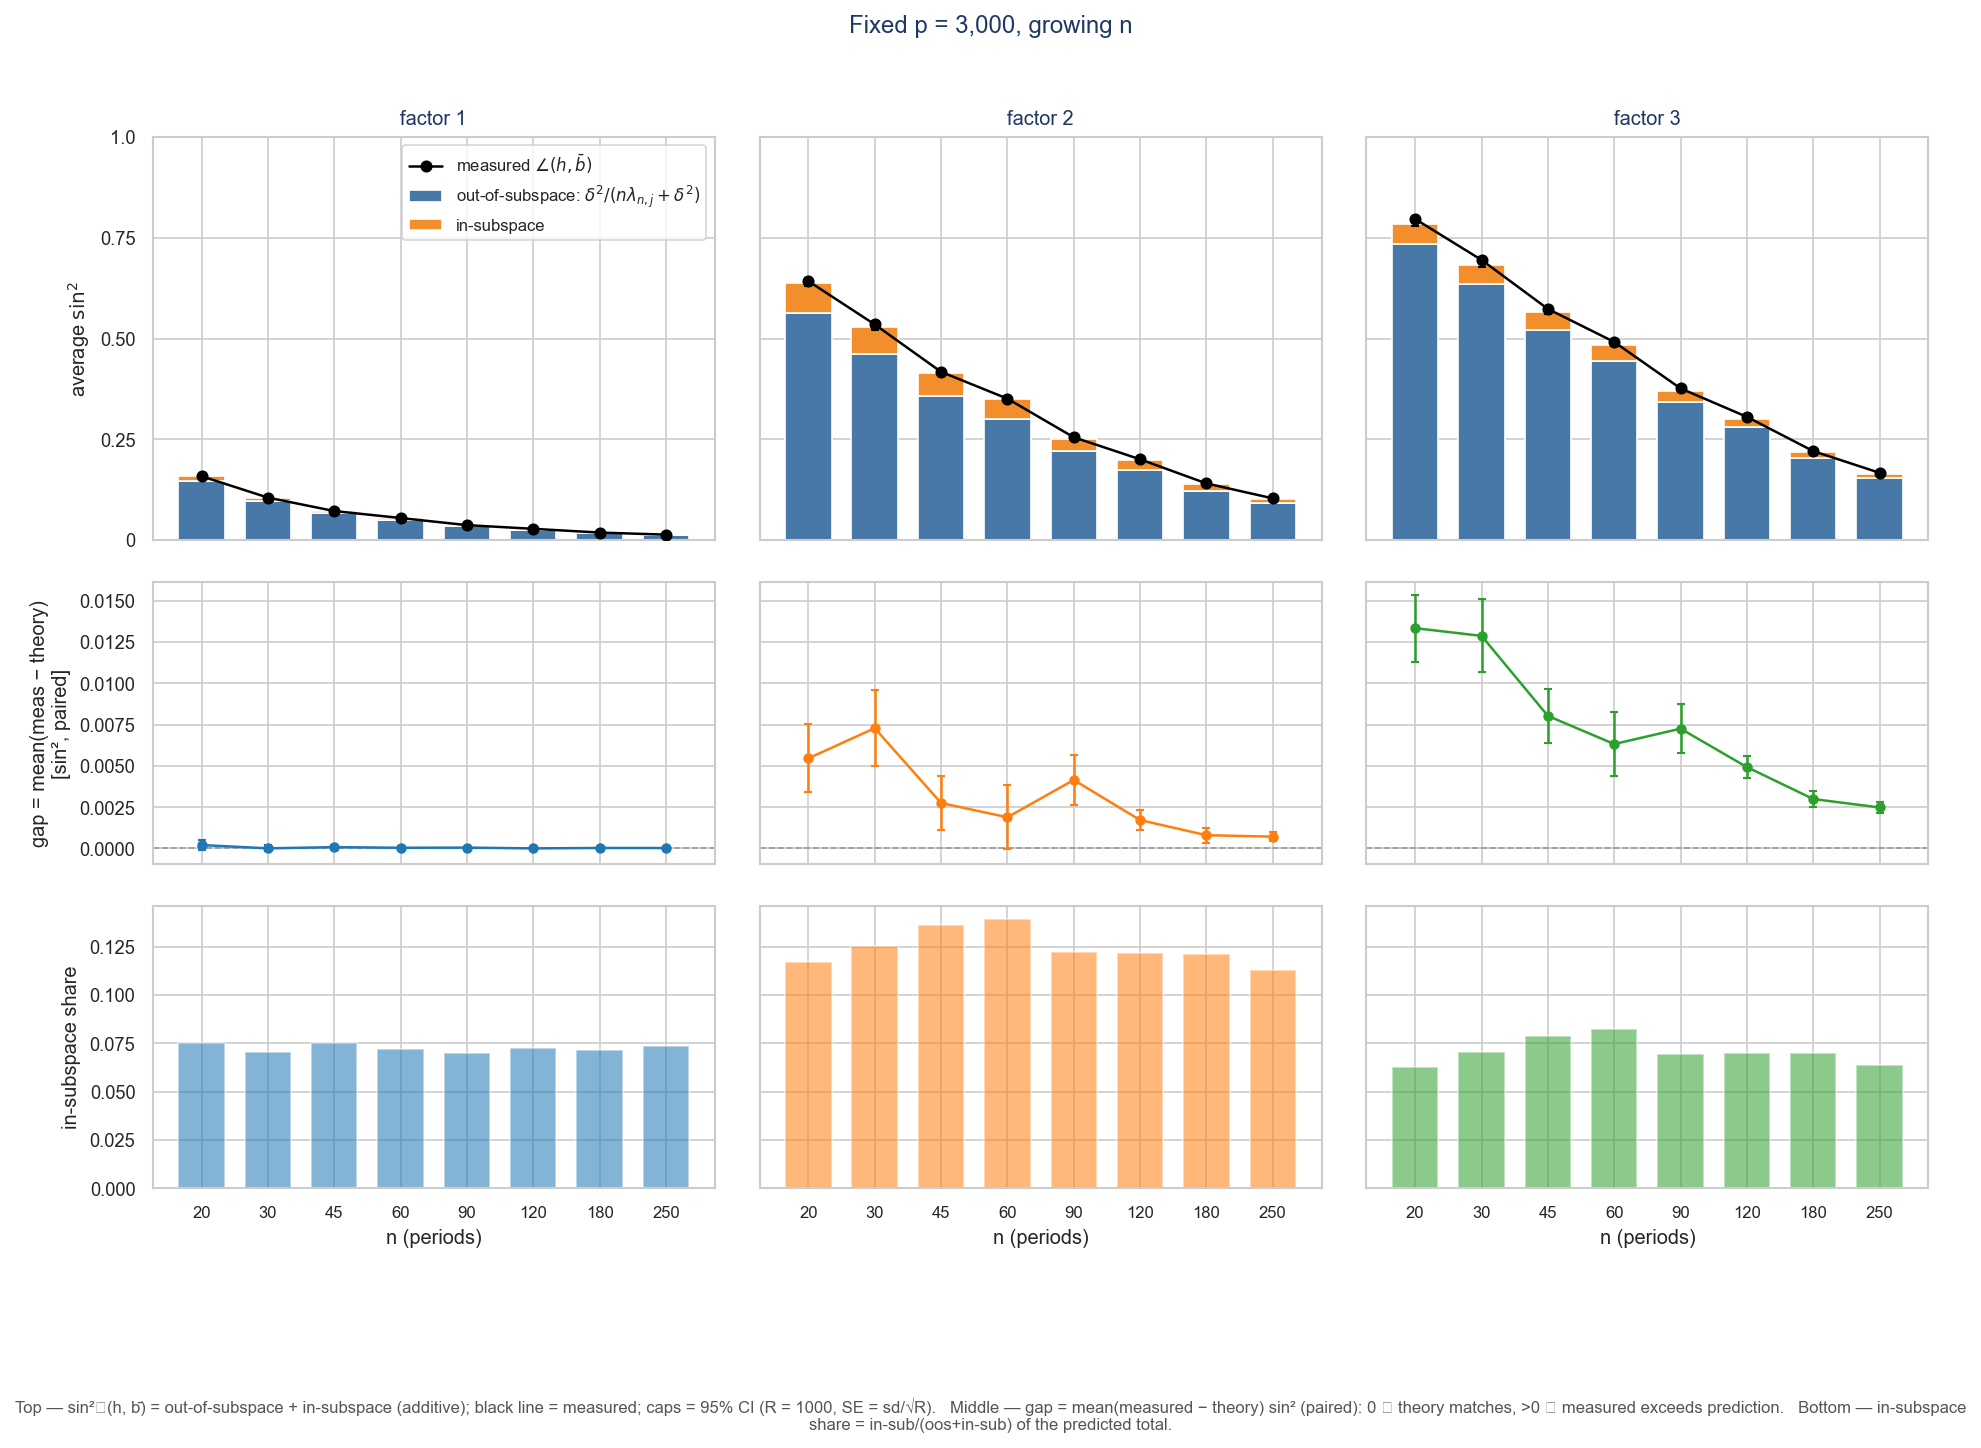

In [9]:
# Fixed p = 3000, growing n: sin^2 decomposition | gap | in-subspace share.
P_FIXED = 3000
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 90, 120, 180, 250], p_values=[P_FIXED],
    n_reps=R_REPS, random_seed=design.random_seed, sampling="nested",
)
df_n = run_experiment(model, design_n, DispersionBiasExperiment())
avg_n = summarize(enrich(df_n), "n")
N_VALUES = sorted(df_n["n"].unique())
fig, axes = plt.subplots(3, 3, figsize=(13.3, 9.6), sharex="col", sharey="row",
                         gridspec_kw={"height_ratios": [1, 0.7, 0.7]})
fig.subplots_adjust(left=0.08, right=0.97, top=0.90, bottom=0.17, hspace=0.13, wspace=0.08)
cats = [str(n) for n in N_VALUES]
for j in (1, 2, 3):
    a = avg_n[avg_n["j"] == j].set_index("n").loc[N_VALUES]
    decomp_panel(axes[0, j-1], cats, a["s2_meas"].to_numpy(), a["s2_oos"].to_numpy(),
                 (a["s2_theory"] - a["s2_oos"]).to_numpy(),
                 meas_se=a["s2_meas_se"].to_numpy(), total_se=a["s2_theory_se"].to_numpy())
    axes[0, j-1].set_title(f"factor {j}", color=NAVY)
    gap_panel(axes[1, j-1], cats, a["gap"].to_numpy(), a["gap_se"].to_numpy(), FACTOR_COLORS[j-1])
    insub = (a["s2_theory"] - a["s2_oos"]).to_numpy()
    frac_panel(axes[2, j-1], cats, insub / a["s2_theory"].to_numpy(), FACTOR_COLORS[j-1])
    axes[2, j-1].set_xlabel("n (periods)")
axes[0, 0].set_ylim(0, 1); axes[0, 0].set_yticks(*SIN2_TICKS); axes[0, 0].set_ylabel(r"average $\sin^2$")
axes[1, 0].set_ylabel("gap = mean(meas − theory)\n[sin², paired]")
axes[2, 0].set_ylabel("in-subspace share")
axes[0, 0].legend(fontsize=8, loc="upper right")
for ax in axes.flat:
    ax.label_outer()
fig.suptitle(f"Fixed p = {P_FIXED:,}, growing n", color=NAVY, y=0.985)
fig.text(0.5, 0.025, CAPTION, ha="center", va="top", fontsize=8, color=GRAY, wrap=True)
fig.savefig(OUT_DIR / "fig_decomp_growing_n.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(OUT_DIR / "fig_decomp_growing_n.png")))

replicate:   0%|          | 0/1000 [00:00<?, ?rep/s]

replicate:   1%|          | 8/1000 [00:00<00:12, 77.71rep/s]

replicate:   2%|▏         | 16/1000 [00:00<00:12, 75.81rep/s]

replicate:   2%|▏         | 24/1000 [00:00<00:15, 61.82rep/s]

replicate:   3%|▎         | 32/1000 [00:00<00:14, 66.50rep/s]

...

replicate:  99%|█████████▊| 987/1000 [00:12<00:00, 78.68rep/s]

replicate: 100%|█████████▉| 995/1000 [00:12<00:00, 78.19rep/s]

replicate: 100%|██████████| 1000/1000 [00:13<00:00, 76.70rep/s]

/private/tmp/ipykernel_55339/3235673254.py:32: UserWarning: Glyph 8736 (\N{ANGLE}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / "fig_decomp_nest_time.png", dpi=150, bbox_inches="tight")


/private/tmp/ipykernel_55339/3235673254.py:32: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / "fig_decomp_nest_time.png", dpi=150, bbox_inches="tight")


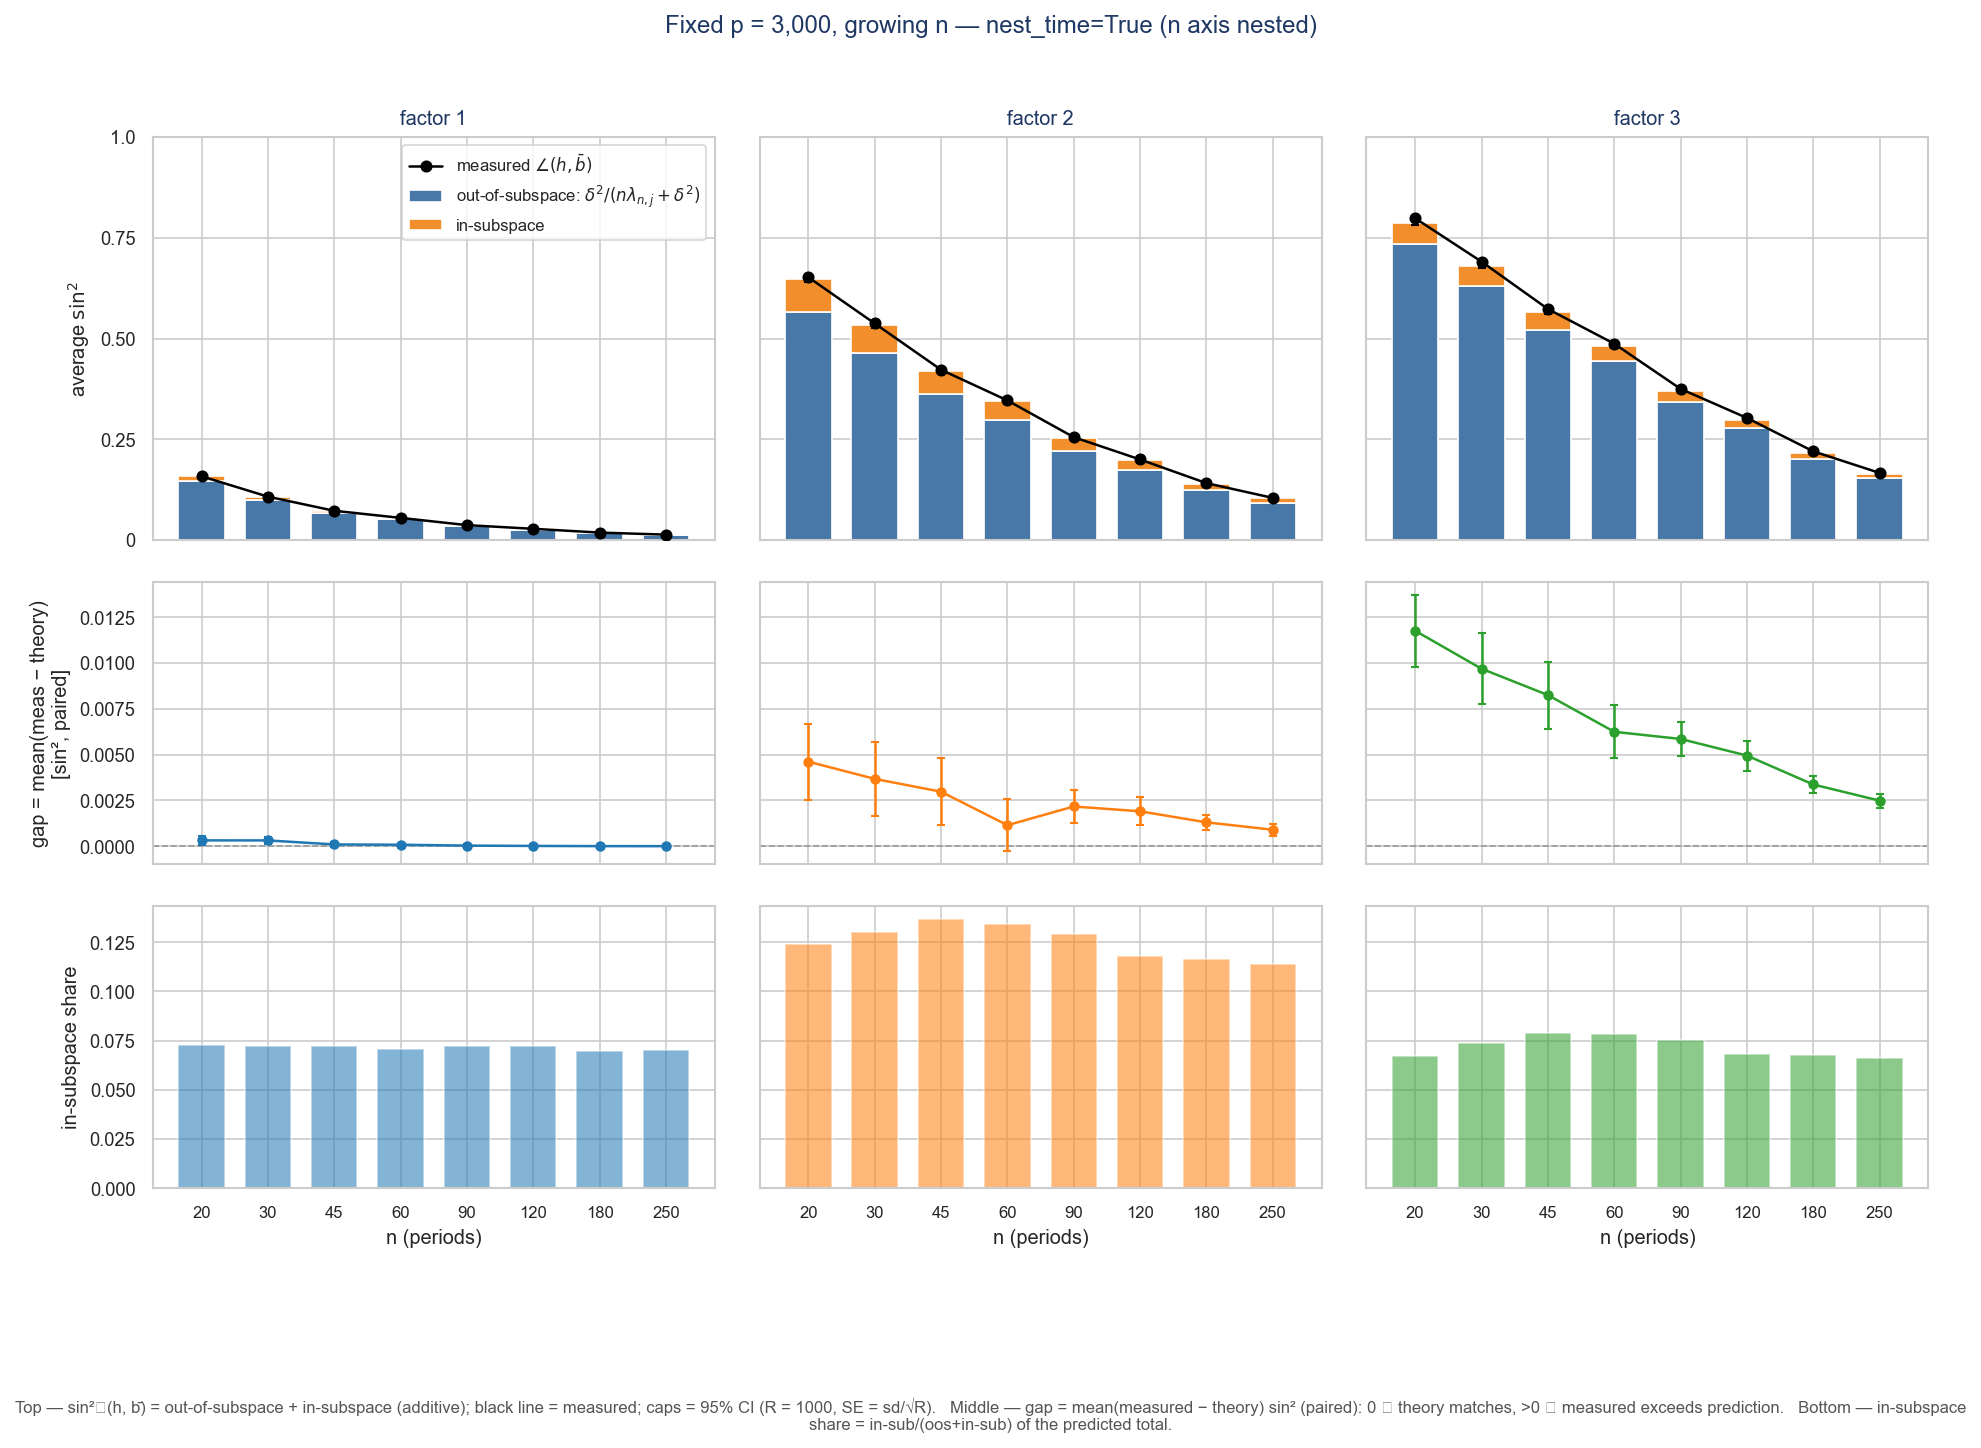

In [10]:
# Same fixed-p = 3000 sweep with nest_time=True (n axis nested): smoother n-curve.
P_FIXED = 3000
design_nt = DesignSpec(
    n_values=[20, 30, 45, 60, 90, 120, 180, 250], p_values=[P_FIXED],
    n_reps=R_REPS, random_seed=design.random_seed, sampling="nested", nest_time=True,
)
df_nt = run_experiment(model, design_nt, DispersionBiasExperiment())
avg_nt = summarize(enrich(df_nt), "n")
N_VALUES_NT = sorted(df_nt["n"].unique())
fig, axes = plt.subplots(3, 3, figsize=(13.3, 9.6), sharex="col", sharey="row",
                         gridspec_kw={"height_ratios": [1, 0.7, 0.7]})
fig.subplots_adjust(left=0.08, right=0.97, top=0.90, bottom=0.17, hspace=0.13, wspace=0.08)
cats = [str(n) for n in N_VALUES_NT]
for j in (1, 2, 3):
    a = avg_nt[avg_nt["j"] == j].set_index("n").loc[N_VALUES_NT]
    decomp_panel(axes[0, j-1], cats, a["s2_meas"].to_numpy(), a["s2_oos"].to_numpy(),
                 (a["s2_theory"] - a["s2_oos"]).to_numpy(),
                 meas_se=a["s2_meas_se"].to_numpy(), total_se=a["s2_theory_se"].to_numpy())
    axes[0, j-1].set_title(f"factor {j}", color=NAVY)
    gap_panel(axes[1, j-1], cats, a["gap"].to_numpy(), a["gap_se"].to_numpy(), FACTOR_COLORS[j-1])
    insub = (a["s2_theory"] - a["s2_oos"]).to_numpy()
    frac_panel(axes[2, j-1], cats, insub / a["s2_theory"].to_numpy(), FACTOR_COLORS[j-1])
    axes[2, j-1].set_xlabel("n (periods)")
axes[0, 0].set_ylim(0, 1); axes[0, 0].set_yticks(*SIN2_TICKS); axes[0, 0].set_ylabel(r"average $\sin^2$")
axes[1, 0].set_ylabel("gap = mean(meas − theory)\n[sin², paired]")
axes[2, 0].set_ylabel("in-subspace share")
axes[0, 0].legend(fontsize=8, loc="upper right")
for ax in axes.flat:
    ax.label_outer()
fig.suptitle(f"Fixed p = {P_FIXED:,}, growing n — nest_time=True (n axis nested)", color=NAVY, y=0.985)
fig.text(0.5, 0.025, CAPTION, ha="center", va="top", fontsize=8, color=GRAY, wrap=True)
fig.savefig(OUT_DIR / "fig_decomp_nest_time.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(OUT_DIR / "fig_decomp_nest_time.png")))